## OBJETIVO 3: Analizar la exigencia y los aspectos relevantes según la nacionalidad de cada usuario (definir pocas nacionalidades)

## 0. Librerías y cargar datos

In [1]:
import pandas as pd
import numpy as np
import spacy

In [2]:
# Cargar datos 
df_base = pd.read_csv('datos/procesados/df_comentarios_traducidos.csv')
display(df_base.head())

# Obtener países con, al menos, 200 comentarios
comentarios_por_pais = df_base['nacionalidad'].value_counts()
paises = comentarios_por_pais[comentarios_por_pais>200].index.tolist()

# Obtenemos un diccionario con dataframes divididos para cada nacionalidad
dfs_paises = {}
for pais in paises:
    dfs_paises[pais] = df_base[df_base['nacionalidad']==pais]

,nombre_del_hotel,nacionalidad,detalles_hab,noches,personas,comentario_general,positivo,negativo,nota,fecha,comentario_media_hotel
0,barceló valencia,colombia,NaN,2,familia,espectacular,espectacular todo! restaurante; servicio; habi...,todo me gustó,10.0,2026-04-14,fabuloso
1,barceló valencia,españa,NaN,1,pareja,muy bien,NaN,NaN,9.0,2026-04-05,fabuloso
2,barceló valencia,españa,2 habitaciones dobles deluxe comunicadas,1,familia,fantástico,"habitaciones amplias, limpieza y ubicación",NaN,9.0,2026-04-03,fabuloso
3,barceló valencia,españa,NaN,1,pareja,todo perfecto,el trato en recepción,el estacionamiento,10.0,2026-03-21,fabuloso
4,barceló valencia,españa,NaN,2,pareja,una nit del foc inolvidable.,las vistas y el tamaño de la habitación.,"la calefacción central, sólo eso.",10.0,2026-03-20,fabuloso


In [3]:
for key, df in dfs_paises.items():
    # Extraer positivos y negativos con su etiqueta
    pos = df[['positivo']].dropna().rename(columns={'positivo': 'text'})
    pos['sentiment'] = 'Positivo'

    neg = df[['negativo']].dropna().rename(columns={'negativo': 'text'})
    neg['sentiment'] = 'Negativo'

    # Combinar ambos en un solo corpus
    df_mixed = pd.concat([pos, neg], ignore_index=True)
    documents = df_mixed['text'].astype(str).tolist()

    print(f"Total de documentos (Pos + Neg) {key}: {len(pos)}+{len(neg)} = {len(documents)}")

Total de documentos (Pos + Neg) españa: 8120+6419 = 14539
Total de documentos (Pos + Neg) italia: 4978+3442 = 8420
Total de documentos (Pos + Neg) reino unido: 2140+1646 = 3786
Total de documentos (Pos + Neg) países bajos: 1958+1568 = 3526
Total de documentos (Pos + Neg) alemania: 1668+1175 = 2843
Total de documentos (Pos + Neg) francia: 1564+1203 = 2767
Total de documentos (Pos + Neg) suiza: 690+519 = 1209
Total de documentos (Pos + Neg) bélgica: 746+617 = 1363
Total de documentos (Pos + Neg) argentina: 859+619 = 1478
Total de documentos (Pos + Neg) estados unidos: 741+514 = 1255
Total de documentos (Pos + Neg) polonia: 555+374 = 929
Total de documentos (Pos + Neg) irlanda: 558+411 = 969
Total de documentos (Pos + Neg) brasil: 545+395 = 940
Total de documentos (Pos + Neg) portugal: 398+322 = 720
Total de documentos (Pos + Neg) austria: 355+235 = 590
Total de documentos (Pos + Neg) ucrania: 214+156 = 370
Total de documentos (Pos + Neg) rumanía: 283+212 = 495
Total de documentos (Pos + 

## 1. Primera prueba: una única nacionalidad
Para realizar las primeras pruebas sobre el proceso de extracción de topics y análisis por nacionalidad nos centraremos en un subconjunto más pequeño de los datos restringiéndolos a una nacionalidad concreta.  
Hemos escogido realizar esta prueba con los comentarios de clientes procedentes de polonia ya que el número de reseñas en este caso es inferior a otras nacionalidades (menor tiempo de ejecución) pero suficientemente grande como para confiar en que podremos extraer conclusiones sólidas. También ha resultado interesante realizar esta prueba para un país no hispanohablante para verificar si el reducido número de reseñas que quedaron sin traducir (la traducción automática no funcionó correctamente) suponen un problema o si utilizar un modelo multilingue permite procesar sin problemas estos datos en el conjunto.

In [4]:
# De momento probamos con una nacionalidad, polonia
key='polonia'
df = dfs_paises['polonia']

# Extraer positivos y negativos con su etiqueta
pos = df[['positivo']].dropna().rename(columns={'positivo': 'text'})
pos['sentiment'] = 'Positivo'

neg = df[['negativo']].dropna().rename(columns={'negativo': 'text'})
neg['sentiment'] = 'Negativo'

# Combinar ambos en un solo corpus
df_mixed = pd.concat([pos, neg], ignore_index=True)
documents = df_mixed['text'].astype(str).tolist()

print(f"Total de documentos (Pos + Neg) {key}: {len(pos)}+{len(neg)} = {len(documents)}")

Total de documentos (Pos + Neg) polonia: 555+374 = 929


### 1.1 Extracción de embeddings y topic modeling
En primer lugar extraeremos los embeddings de cada reseña, utilizando un SentenceTransformer para que se tenga en cuenta el contexto de oraciones completas, en lugar de solamente cada palabra por separado.  
Estos embeddings se extraen con el texto traducido, sin emojis y en minúsculas, pero sin lematización ni eliminación de stopwords.  
Posteriormente utilizaremos BERTopic para extraer los temas, la clusterización se realizará con los embeddings calculados pero para posteriormente asignar sentido a cada tema con TF-IDF eliminaremos ciertas stopwords (algunas resultan relevantes si son adjetivos descriptivos).

In [5]:
# Extracción de embeddings
from sentence_transformers import SentenceTransformer

#embedding_model = SentenceTransformer("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")
embedding_model = SentenceTransformer("sentence-transformers/paraphrase-multilingual-mpnet-base-v2")
embeddings = embedding_model.encode(documents, show_progress_bar=True)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/30 [00:00<?, ?it/s]

In [6]:
from bertopic import BERTopic
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer
import spacy

# Reducción de dimensionalidad y Clustering
umap_model = UMAP(n_neighbors=15, n_components=3, min_dist=0.0, metric='cosine', random_state=42)

hdbscan_model = HDBSCAN(min_cluster_size=20, min_samples=10, metric='euclidean', cluster_selection_method='eom', prediction_data=True)

# Vectorizador para limpiar palabras vacías en los resultados

# Utilizamos spacy para obtener las stopwords del español
nlp = spacy.load('es_core_news_sm')
# Cargamos las stopwords de spaCy
stopwords_es = list(nlp.Defaults.stop_words)
# Analizamos las stopwords, vemos si interesa eliminar o añadir palabras
print(stopwords_es)

['hago', 'tuya', 'éste', 'este', 'segundo', 'partir', 'ultimo', 'si', 'varias', 'tres', 'habla', 'qeu', 'según', 'además', 'voy', 'tuyo', 'explicó', 'cuenta', 'puede', 'más', 'algunos', 'unos', 'eras', 'ser', 'en', 'podria', 'saben', 'usas', 'todo', 'os', 'verdadera', 'sido', 'tenido', 'mios', 'estuvo', 'tuyos', 'vaya', 'nuevos', 'quiere', 'estamos', 'diez', 'han', 'quien', 'acuerdo', 'tu', 'poco', 'esos', 'cierta', 'ambos', 'la', 'haces', 'sabemos', 'el', 'manera', 'tuyas', 'conocer', 'ha', 'hay', 'tarde', 'cierto', 'repente', 'ese', 'tendrá', 'haceis', 'vuestras', 'durante', 'ver', 'estados', 'estaba', 'nos', 'tiene', 'días', 'sola', 'haciendo', 'serán', 'largo', 'tercero', 'quienes', 'podemos', 'tenía', 'ti', 'últimas', 'pues', 'otros', 'varios', 'tengo', 'estaban', 'última', 'señaló', 'cuánto', 'cuando', 'quizas', 'también', 'u', 'lo', 'ir', 'todavia', 'cuantas', 'sean', 'debido', 'ella', 'están', 'he', 'para', 'fuera', 'sea', 'bajo', 'enfrente', 'añadió', 'esta', 'con', 'pronto', 

In [7]:
# # Eliminamos stopwords que puedan resultar relevantes
# relevantes = ['mejor', 'buenas', 'pronto', 'bastante', 'no', 'más', 'buenos', 'pocos', 'apenas', 'deprisa',
#                      'despacio', 'tampoco', 'buena']
# for palabra in relevantes:
#     stopwords_es.remove(palabra)
    
# Añadimos palabras que no nos interesen específicamente de hoteles para separar entre positivo o negativo
stopwords_es.extend(["hotel", "valencia", "habitacion", "habitación"])

#Configuramos el vectorizador
# El token_pattern r"(?u)\b[a-zA-ZáéíóúÁÉÍÓÚñÑ]{2,}\b" obliga a que los tokens:
# - Tengan al menos 2 caracteres.
# - Solo contengan letras (incluyendo tildes y ñ), eliminando así los números.
vectorizer_model = CountVectorizer(
    stop_words=stopwords_es, #ademas de quitar las stopwords
    token_pattern=r"(?u)\b[a-zA-ZáéíóúÁÉÍÓÚñÑ]{2,}\b"
)

# Al crear el modelo, le pasamos este vectorizador
topic_model = BERTopic(
    embedding_model=embedding_model,
    vectorizer_model=vectorizer_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    language="multilingual"
)

# Aquí puedes usar los documents originales sin problemas
topics, probs = topic_model.fit_transform(documents, embeddings)
df_mixed["topic"] = topics

A continuación analizaremos los temas obtenidos y las opiniones de los huéspedes respecto a cada uno de ellos en base a las reseñas positivas y negativas de cada uno de ellos.

In [8]:
# Ver la distribución de sentimiento por cada tema encontrado
df_distribucion = df_mixed.groupby(['topic', 'sentiment']).size().unstack(fill_value=0)
df_distribucion['Total'] = df_distribucion.sum(axis=1)
df_distribucion['% Positivo'] = (df_distribucion['Positivo'] / df_distribucion['Total'] * 100).round(2)

print("Distribución de sentimiento por Topic (¿Hubo separación?):")
display(df_distribucion)

# Mostrar palabras clave de los temas con más "Negativos" y más "Positivos"
topic_info = topic_model.get_topic_info()
display(topic_info.head(10))

Distribución de sentimiento por Topic (¿Hubo separación?):


sentiment,Negativo,Positivo,Total,% Positivo
topic,,,,
0,294,473,767,61.67
1,39,43,82,52.44
2,21,10,31,32.26
3,0,28,28,100.00
4,20,1,21,4.76


,Topic,Count,Name,Representation,Representative_Docs
0,0,767,0_ubicación_desayuno_personal_excelente,"[ubicación, desayuno, personal, excelente, cer...","[muy buen desayuno. excelente ubicación, excel..."
1,1,82,1_cara_falta_sonriendo_enie,"[cara, falta, sonriendo, enie, po, ligeramente...",[si ownia 400 m2 cara sonriendo con estrellas ...
2,2,31,2_seria_genial_ok_estaría,"[seria, genial, ok, estaría, gusta, gustó, gus...","[todo seria genial, todo seria genial, todo se..."
3,3,28,3_ubicación_localización_clima_central,"[ubicación, localización, clima, central, pura...","[ubicación, ubicación, ubicación]"
4,4,21,4_cosa_nic_comentarios_hablar,"[cosa, nic, comentarios, hablar, cosas, página...","[no sobre tal cosa:, no sobre tal cosa. : :, n..."


Analizamos también algunos ejemplos de reseñas para cada topic:

In [9]:
for topic in np.unique(topics):
    if topic == -1:
        continue

    print(f'======= TOPIC  {topic} =======')
    # Mostramos palabras clave
    words = topic_model.get_topic(topic)
    topic_words = [word for word, score in words[:5]]
    print('Palabras clave: ', ' '.join(topic_words))

    # Mostramos tres ejemplos de comentarios positivos y negativos (si hay)
    # Positivos
    if df_distribucion['Positivo'][topic] >= 3:
        print('\n Comentarios positivos')
        aux = df_mixed[df_mixed['sentiment']=='Positivo'][df_mixed['topic']==topic].sample(3)
        aux = aux['text'].tolist()
        print('\n'.join(aux))

    elif df_distribucion['Positivo'][topic] > 0:
        print('\n Comentarios positivos')
        aux = df_mixed[df_mixed['sentiment']=='Positivo'][df_mixed['topic']==topic]

    # Negativos 
    if df_distribucion['Negativo'][topic] >= 3:
        print('\n Comentarios negativos')
        aux = df_mixed[df_mixed['sentiment']=='Negativo'][df_mixed['topic']==topic].sample(3)
        aux = aux['text'].tolist()
        print('\n'.join(aux))

    elif df_distribucion['Negativo'][topic] > 0:
        print('\n Comentarios negativos')
        aux = df_mixed[df_mixed['sentiment']=='Negativo'][df_mixed['topic']==topic]
        aux = aux['text'].tolist()
        print('\n'.join(aux))


======= TOPIC  0 =======
Palabras clave:  ubicación desayuno personal excelente cerca

 Comentarios positivos
comida muy buena
La ubicación es perfecta, buena relación calidad-precio y ¡hay aire acondicionado! lo que realmente ayuda a soportar el clima a finales de agosto
todo. Nos gustó un hombre en la recepción que se ocupó de inmediato de los problemas menores que surgieron. Nos encantó la idea de limpiar el parabrisas antes de partir. eso fue realmente dulce:

 Comentarios negativos
insonorizar la habitación
larga espera para el ascensor
En booking.com decía una habitación con 9 camas, cuando en realidad las habitaciones tienen 10 camas cada una. Eso fue un error mientras hacía la reserva.
======= TOPIC  1 =======
Palabras clave:  cara falta sonriendo enie po

 Comentarios positivos
, , .                          .                        , , .                      , !                     , .                        .                             !
vista perfecta
            ,        

Este procedimiento no parece llevar a resultados muy concluyentes, al menos para la nacionalidad probada.

### 2. Tratar de aplicar el procedimiento a varias nacionalidades (Creo que esto ni vale la pena)
El procedimiento no parece haber permitido extraer conclusiones relevantes para la nacionalidad probada. A continuación lo aplicaremos a todo el conjunto de nacionalidades para evaluar si este se trata de un problema puntual o global, o si de aunque los topics extraídos no parezcan ser satisfactorios por sí mismos se puede igualmente extraer conclusiones relevantes al compararlos.

### 1.2. Análisis clásico
Ya que el topic modeling probado no ha llevado a resultados muy concluyentes a continuación realizaremos un análisis clásico de las reseñas basado en frecuencias de palabras. 

#### 1.2.1 TF-IDF
Utilizaremos TF-IDF para extraer los términos más relevantes para cada nacionalidad (DELTA TF-IDF).  

En primer lugar preprocesaremos los datos para mejorar la aplicación de TF-IDF, esto incluirá la eliminación de stopwords y lematización.

In [10]:
# En primer lugar eliminamos stopwords para mejores resultados

# Utilizamos spacy para obtener las stopwords del español
nlp = spacy.load('es_core_news_sm')
# Cargamos las stopwords de spaCy
stopwords_es = list(nlp.Defaults.stop_words)
# Analizamos las stopwords, vemos si interesa eliminar o añadir palabras
#print(stopwords_es)

# Eliminamos stopwords que puedan resultar relevantes
relevantes = ['mejor', 'buenas', 'pronto', 'bastante', 'no', 'más', 'buenos', 'pocos', 'apenas', 'deprisa',
                     'despacio', 'tampoco', 'buena']
for palabra in relevantes:
    stopwords_es.remove(palabra)
    
# # Añadimos palabras que no nos interesen específicamente de hoteles para separar entre positivo o negativo
# stopwords_es.extend(["hotel", "valencia", "habitacion", "habitación"])

# Función para la normalización
def normalizar_doc(doc):
    '''Función que normaliza un texto cogiendo sólo
    las palabras en minúsculas mayores de 2 caracteres'''
    # separamos en tokens
    tokens = nlp(doc)
    # filtrar que las palabras tengan al menos tres caracteres y eliminamos stopwords de nuestra lista
    filtered_tokens = [t.text for t in tokens if
                       len(t.text)>=3 and t.text not in stopwords_es]
    # juntamos de nuevo en una cadena
    doc = ' '.join(filtered_tokens)
    return doc

# Función para la lematización
def LemmaSentence(sentence):
    nlp = spacy.load("en_core_web_sm")
    doc = nlp(sentence)
    lemmas = [token.lemma_ for token in doc]
    # Juntamos el texto
    lemmatized_text = ' '.join(lemmas)

    return lemmatized_text

# Documentos normalizados
norm_docs = list(map(normalizar_doc, documents))
# Documentos normalizados y lematizados
lemma_docs = [LemmaSentence(doc) for doc in norm_docs]

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer

tv = TfidfVectorizer(ngram_range=(2,2), min_df=0.003, max_df=0.6, norm=None) # Palabras únicas son difíciles de interpretar, nos centramos en bigramas y trigramas
# Hacemos fit de tv a los comentarios tanto positivos como negativos
tv_sparse_matrix = tv.fit_transform(lemma_docs)

tv_matrix = tv_sparse_matrix.toarray()
vocab_bigram = tv.get_feature_names_out()

# Obtenemos los 40 elementos de mayor peso (más adelante evaluaremos cuántos conviene utilizar para comparar)
idx_top = np.argsort(tv_matrix.max(axis=0))[-40:]
palabras_top = vocab_bigram[idx_top]
print(palabras_top)

['limpio ordenado' 'cargar teléfono' 'cama limpia' 'lugar alojarse'
 'mala calidad' 'limpieza habitación' 'metro minuto' 'cama cómodas'
 'cama almohada' 'más importante' 'natural habitación'
 'necesita renovación' 'nos encantó' 'minuto andando'
 'limpieza habitacione' 'acceso luz' 'cerca atracciones' 'cerca ascensor'
 'cerca aeropuerto' 'hotel justo' 'hotel hotel' 'limpieza diaria'
 'centro tranquilo' 'in check' 'hotel recomiendo' 'centro palma'
 'justo playa' 'las camas' 'lejos centro' 'limpia personal'
 'limpieza comodidad' 'cama cómoda' 'aire acondicionado' 'check in'
 'preparar café' 'estación tren' 'vale pena' 'luz natural'
 'habitación preparar' 'estación principal']


A continuación trataremos de estimar cómo se sienten los clientes acerca de cada uno de los términos de gran importancia nombrados evaluando la proporción de apariciones que tienen estas palabras en reseñas positivas vs negativas.

In [12]:
# Obtener proporción de cada término en reseñas positivas/negativas
# Utilizamos un dataframe auxiliar para reco
df_tv = pd.DataFrame(np.round(tv_matrix, 2), columns=vocab_bigram)

# Creamos variable de dataframe para la proporción de cada término
df_prop_tv = None

# Recorremos cada término
for ngrama in palabras_top:
    # Encontrar el índice de los documentos en los que su score no es 0, usarlo en df_mixed para hallar el tipo de reseña
    sentimientos = df_mixed['sentiment'][df_tv[ngrama]!=0.0].to_numpy()
    # Proporción positivos
    prop_pos = np.sum(sentimientos=='Positivo')/len(sentimientos)
    # Proporción negativos
    prop_neg = np.sum(sentimientos=='Negativo')/len(sentimientos)
    # Si el dataframe no existe lo creamos, si ya existe se inserta una nueva fila
    if isinstance(df_prop_tv, pd.DataFrame): 
        df_prop_tv.loc[len(df_prop_tv)] = [ngrama, prop_pos, prop_neg]
    else:
        df_prop_tv = {'Término': [ngrama], 'Proporcion positivo': [prop_pos], 'Proporcion negativo': [prop_neg]}
        df_prop_tv = pd.DataFrame(df_prop_tv)
    
# Vemos cómo quedaría en los 10 primeros casos
display(df_prop_tv.head(20))

,Término,Proporcion positivo,Proporcion negativo
0,limpio ordenado,0.666667,0.333333
1,cargar teléfono,1.000000,0.000000
2,cama limpia,1.000000,0.000000
3,lugar alojarse,0.666667,0.333333
4,mala calidad,0.000000,1.000000
5,limpieza habitación,1.000000,0.000000
6,metro minuto,1.000000,0.000000
7,cama cómodas,1.000000,0.000000
8,cama almohada,1.000000,0.000000
9,más importante,1.000000,0.000000


#### 1.2.2 Log Odds Ratio
A la hora de analizar frecuencias de palabras en documentos, una alternativa a los métodos TF-IDF o Bag of Words es el Log Odds Ratio, esta métrica tratará de evaluar la probabilidad de encontrar una palabra o n-grama en una determinada categoría (en nuestro caso, una nacionalidad) respecto a la probabilidad de que esta palabra se encuentre en otra categoría.  
https://antonio-velazquez-bustamante.medium.com/comparing-political-speeches-with-python-and-nlp-54cd506e91b9  
https://acua.qcri.org/blog/log-odds-ratio-going-beyond-simple-term-frequencies-to-characterize-textual-categories/  
(El artículo del que dicen que sale esto pero no nos vamos a leer, o no entero: https://www.cambridge.org/core/journals/political-analysis/article/fightin-words-lexical-feature-selection-and-evaluation-for-identifying-the-content-of-political-conflict/81B3703230D21620B81EB6E2266C7A66 )  
Dado que este es un método directamente comparativo no podemos hacer esta primera prueba solamente con los datos de una nacionalidad, por lo que escogeremos una segunda nacionalidad con la que comparar (más adelante ya se realizará para todas las nacionalidades).  

In [13]:
# Compararemos con, por ejemplo, las reseñas de Portugal
df2 = dfs_paises['portugal']

# Extraer positivos y negativos con su etiqueta
pos2 = df2[['positivo']].dropna().rename(columns={'positivo': 'text'})
pos2['sentiment'] = 'Positivo'

neg2 = df2[['negativo']].dropna().rename(columns={'negativo': 'text'})
neg2['sentiment'] = 'Negativo'

# Combinar ambos en un solo corpus
df_mixed2 = pd.concat([pos2, neg2], ignore_index=True)
documents_por = df_mixed2['text'].astype(str).tolist()

print(f"Total de documentos (Pos + Neg) portugal: {len(pos2)}+{len(neg2)} = {len(documents_por)}")

# Preprocesado
# Documentos normalizados
norm_docs_por = list(map(normalizar_doc, documents_por))
# Documentos normalizados y lematizados
lemma_docs_por = [LemmaSentence(doc) for doc in norm_docs_por]

Total de documentos (Pos + Neg) portugal: 398+322 = 720


Para calcular el z-score de log odds partimos de las cuentas de cada palabra en cada documento, y en total, para realizar esta parte de manera rápida y automática utilizaremos Bag of Words de spacy. Como lo que queremos saber es la frecuencia de las palabras para cada nacionalidad necesitaremos tener un corpus completo común, uniremos los dos corpus normalizados que tenemos creando también una nueva variable (etiquetas) que permita consultar posteriormente a qué nacionalidad pertenece cada documento.

In [14]:
# Corpus completo
ldocs_total = lemma_docs + lemma_docs_por
# Etiquetas nacionalidad, de aquí sacaremos los índices para filtrar posteriormente
nacionalidad_docs = np.array(['polonia']*len(lemma_docs) + ['portugal']*len(lemma_docs_por))

# Bag of words del corpus completo
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(ngram_range=(1,2), min_df=0.003, max_df=0.6)
cv_matrix_sparse = cv.fit_transform(ldocs_total)
cv_matrix = cv_matrix_sparse.toarray()

vocab = cv.get_feature_names_out()
# Guardamos las cuentas en un dataframe para tener referencia de a qué término pertenece cada uno
df_bow_total = pd.DataFrame(cv_matrix, columns=vocab)

# Ahora creamos otro dataframe que permita obtener las cuentas de cada término por nacionalidad (agrupando)
# cuentas palabras polonia (pol) y portugal (port)
pol = df_bow_total.loc[np.array(nacionalidad_docs)=='polonia',:].sum(axis=0)
port = df_bow_total.loc[np.array(nacionalidad_docs)=='portugal',:].sum(axis=0)
# dataframe completo
df_counts = pd.concat([pol, port], axis=1).transpose()
df_counts = df_counts.rename(index={0: 'polonia', 1: 'portugal'})
display(df_counts)

,00,abierta,abrir,absolutamente,absoluto,acceso,acogedor,acondicionado,actividade,actividades,...,vistas,wifi,zona,zonas,zumo,área,único,único inconveniente,útil,útile
polonia,10,5,5,8,5,15,4,30,3,2,...,9,9,10,2,4,9,8,5,8,4
portugal,4,1,3,2,4,14,4,22,2,4,...,5,2,13,5,1,6,8,2,1,1


Ahora que ya tenemos las apariciones de cada n-grama divididas por nacionalidad trataremos de implementar el cálculo del score correspondiente a Log Odds Ratio. Este score se calcularía así:  
$$ \log{\frac{p_1}{(1-p_1)}}=\log{\frac{p_1}{p_2}} = \log{p_1} - \log{p_2} $$

donde $p_1$ es la probabilidad de que un cierto n-grama aparezca en el corpus 1 y $p_2$ la probabilidad de que aparezca en el corpus 2. Si se trabaja con cuentas de cada palabra, $c_1$ para las apariciones en el corpus 1 y $c_2$ para sus apariciones en el corpus 2 (donde $\Sigma c_1$ y $\Sigma c_2$ son el número total de n-gramas que aparecen en cada corpus) el término se reescribe como:

$$ \log{\frac{c_1}{\Sigma c_1}} - \log{\frac{c_2}{\Sigma c_2}} = \log{c_1} - \log{\Sigma c_1} - \log{c_2} + \log{\Sigma c_2} $$

Adicionalmente, con tal de evitar posibles errores cuando alguno de estos términos ($c_1$ o $c_2$) es 0 y suavizar la función se añade tanto a $c_1$ como a $c_2$ una pequeña cantidad determinada por un parámetro $\alpha$.

In [15]:
pd.DataFrame(data=np.zeros((1, df_counts.shape[1])), columns=df_counts.columns, index=[0])

,00,abierta,abrir,absolutamente,absoluto,acceso,acogedor,acondicionado,actividade,actividades,...,vistas,wifi,zona,zonas,zumo,área,único,único inconveniente,útil,útile
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [16]:
# Parámetro de suavizado
alpha = 0.01
# Cuentas totales
c1_total = df_counts.loc['polonia',:].sum()
c2_total = df_counts.loc['portugal',:].sum()
# Dataframe para guardar los resultados
logodds = pd.DataFrame(data=np.zeros((1, df_counts.shape[1])), columns=df_counts.columns, index=[0])

# Iteramos sobre cada término
for col in df_counts.columns.tolist():
    # Cuentas
    c1 = df_counts.loc['polonia', col]
    c2 = df_counts.loc['portugal', col]

    # Suavizado
    c1 += alpha
    c2 += alpha

    # Calcular score
    zscore = np.log(c1) - np.log(c1_total) - np.log(c2) + np.log(c2_total)

    # Guardar score en logodds
    logodds.loc[0,col] = zscore

# Guardamos logodds ordenado
logodds = logodds.sort_values(by=0, axis=1)
logodds

,localiza,ubica,estructura,destacar,desayuno cena,quedarme,pequeno,almo,pequeno almo,localizar,...,cosméticos,estándar,delicioso desayuno,hervidor agua,ubicación centro,vista ventana,deliciosos,posibilidad,selección,sabroso
0,-8.819021,-7.279448,-7.161804,-7.161804,-7.161804,-7.161804,-7.161804,-7.028451,-7.028451,-7.028451,...,6.614967,6.614967,6.694946,6.694946,6.768999,6.902441,6.902441,7.220724,7.265156,7.348503


## 3. Todas las nacionalidades

En esta fase del proyecto identificamos y filtramos el dataset para quedarnos únicamente con las diez nacionalidades que acumulan el mayor volumen de reseñas, garantizando así la solidez estadística del estudio. Hemos desarrollado un algoritmo de limpieza que aplicamos de forma independiente a los comentarios positivos y negativos. Con esta función eliminamos respuestas evasivas tipo "nada" y lematizamos cada palabra para reducirla a su raíz semántica, obteniendo así un corpus completamente normalizado y listo para la extracción de conclusiones.

In [17]:
import pandas as pd
import numpy as np
import spacy
from sklearn.feature_extraction.text import TfidfVectorizer

# Detectamos automáticamente las 10 nacionalidades con más reseñas
nacionales_top = df_base['nacionalidad'].value_counts().head(10).index.tolist()
print(f"Nacionalidades principales detectadas para el estudio: {nacionales_top}")

# Creamos el DataFrame de trabajo filtrado
df_proyecto = df_base[df_base['nacionalidad'].isin(nacionales_top)].copy()

# Cargar spaCy en español
nlp = spacy.load('es_core_news_sm')
stopwords_es = list(nlp.Defaults.stop_words)

# Rescatamos palabras clave que indican queja o cuantificación
relevantes = ['mejor', 'buenas', 'no', 'más', 'buenos', 'pocos', 'apenas', 'tampoco', 'buena', 'bastante']
for palabra in relevantes:
    if palabra in stopwords_es:
        stopwords_es.remove(palabra)

# Añadimos palabras obvias que sesgan el análisis de hoteles
stopwords_es.extend(["hotel", "valencia", "habitacion", "habitación", "alojamiento", "estancia", "establecimiento"])

def limpiar_y_lematizar(texto):
    """Transforma el texto a minúsculas, elimina stopwords y extrae la raíz (lema)"""
    if pd.isna(texto) or str(texto).strip() == "" or str(texto).lower() == "ninguna" or str(texto).lower() == "nada":
        return ""
    
    doc = nlp(str(texto).lower())
    # Filtramos por longitud y stopwords, extrayendo el lema
    tokens_limpios = [token.lemma_ for token in doc if token.text not in stopwords_es and len(token.text) >= 3]
    return ' '.join(tokens_limpios)

print("Limpiando textos de reseñas... Esto puede tardar un par de minutos.")
# Aplicamos la limpieza de forma independiente a la columna de positivos y de negativos
df_proyecto['positivo_clean'] = df_proyecto['positivo'].apply(limpiar_y_lematizar)
df_proyecto['negativo_clean'] = df_proyecto['negativo'].apply(limpiar_y_lematizar)
print("¡Textos listos y normalizados!")

Nacionalidades principales detectadas para el estudio: ['españa', 'italia', 'reino unido', 'países bajos', 'alemania', 'francia', 'suiza', 'bélgica', 'argentina', 'estados unidos']
Limpiando textos de reseñas... Esto puede tardar un par de minutos.
¡Textos listos y normalizados!


Construimos una función para extraer las combinaciones de dos palabras más relevantes de cada país mediante TF-IDF. En primer lugar, el algoritmo filtra el conjunto de datos segmento por segmento para aislar las reseñas de cada nacionalidad y configura un vectorizador para identificar bigramas que aparezcan al menos dos veces. Posteriormente, calculamos el peso medio de cada pareja de palabras sobre la matriz TF-IDF generada, lo que nos permite ordenar los términos y seleccionar los diez conceptos con mayor impacto semántico para cada pasaporte. 

In [18]:
def extraer_bigramas_tfidf(df, pais, columna_texto, top_n=10):
    """Extrae los bigramas con mayor peso TF-IDF para un país en la columna indicada"""
    # Filtramos por país y nos aseguramos de que haya texto real
    df_segmento = df[(df['nacionalidad'] == pais) & (df[columna_texto] != "")]
    
    if len(df_segmento) < 5:
        return ["Datos insuficientes"]
    
    # Configuramos el vectorizador para extraer parejas de palabras (bigramas)
    vectorizer = TfidfVectorizer(ngram_range=(2, 2), max_df=0.95, min_df=2)
    tfidf_matrix = vectorizer.fit_transform(df_segmento[columna_texto])
    
    # Calculamos el peso medio de cada bigrama
    pesos_medios = tfidf_matrix.mean(axis=0).A1
    vocabulario = vectorizer.get_feature_names_out()
    
    # Ordenamos los índices de mayor a menor peso
    indices_top = np.argsort(pesos_medios)[-top_n:][::-1]
    
    return [vocabulario[i] for i in indices_top]

lineas_resultados = []

for pais in nacionales_top:
    # Extraer lo mejor de cada país (de la columna positivo)
    top_positivos = extraer_bigramas_tfidf(df_proyecto, pais, 'positivo_clean')
    lineas_resultados.append({
        'Nacionalidad': pais.upper(),
        'Bloque Analizado': 'Halagos (Columna Positivo)',
        'Top Bigramas Relevantes': ", ".join(top_positivos)
    })
    
    # Extraer lo peor de cada país (de la columna negativo)
    top_negativos = extraer_bigramas_tfidf(df_proyecto, pais, 'negativo_clean')
    lineas_resultados.append({
        'Nacionalidad': pais.upper(),
        'Bloque Analizado': 'Quejas (Columna Negativo)',
        'Top Bigramas Relevantes': ", ".join(top_negativos)
    })

# Convertimos a DataFrame para una visualización limpia
df_final_insights = pd.DataFrame(lineas_resultados)
display(df_final_insights)

,Nacionalidad,Bloque Analizado,Top Bigramas Relevantes
0,ESPAÑA,Halagos (Columna Positivo),"personal amable, cama cómodo, trato personal, ..."
1,ESPAÑA,Quejas (Columna Negativo),"baño pequeño, aire acondicionado, ruido calle,..."
2,ITALIA,Halagos (Columna Positivo),"excelente ubicación, personal amable, ubicació..."
3,ITALIA,Quejas (Columna Negativo),"aire acondicionado, baño pequeño, único defect..."
4,REINO UNIDO,Halagos (Columna Positivo),"excelente ubicación, personal amable, ubicació..."
5,REINO UNIDO,Quejas (Columna Negativo),"aire acondicionado, ascensor lento, baño peque..."
6,PAÍSES BAJOS,Halagos (Columna Positivo),"personal amable, ubicación perfecto, excelente..."
7,PAÍSES BAJOS,Quejas (Columna Negativo),"aire acondicionado, cama duro, baño pequeño, s..."
8,ALEMANIA,Halagos (Columna Positivo),"excelente ubicación, personal amable, buen ubi..."
9,ALEMANIA,Quejas (Columna Negativo),"aire acondicionado, quejar él, sala desayuno, ..."


Calculamos la media global de cada país junto al total de reseñas.

In [19]:
print("\n--- ANÁLISIS DE EXIGENCIA CUANTITATIVA ---")
analisis_notas = df_proyecto.groupby('nacionalidad').agg(
    nota_media_global=('nota', 'mean'),
    total_reseñas=('nota', 'count')
).round(2).sort_values(by='nota_media_global')

display(analisis_notas)


--- ANÁLISIS DE EXIGENCIA CUANTITATIVA ---


,nota_media_global,total_reseñas
nacionalidad,,
alemania,8.25,3122
españa,8.30,16915
bélgica,8.35,1335
francia,8.38,2684
suiza,8.38,1364
países bajos,8.39,3153
italia,8.64,9377
argentina,8.71,1334
reino unido,8.71,3355


Definimos una función para cuantificar el nivel de enfado expresado en cada reseña. Para ello, definimos una lista con términos específicos de amplificación negativa en español. Se contabiliza cuántas de estas palabras aparecen en cada comentario negativo individual.

In [20]:
# Definimos una lista de amplificadores de queja en español
amplificadores = ['muy', 'bastante', 'demasiado', 'fatal', 'pesimo', 'pésimo', 'malisimo', 'malísimo', 'nunca', 'jamas', 'jamás']

def calcular_intensidad_queja(texto):
    if pd.isna(texto): return 0
    palabras = str(texto).lower().split()
    # Contamos cuántas palabras de la reseña son amplificadores negativos
    coincidencias = sum(1 for p in palabras if p in amplificadores)
    return coincidencias

# Aplicamos a la columna original de negativos
df_proyecto['intensidad_negativa'] = df_proyecto['negativo'].apply(calcular_intensidad_queja)

# Calculamos la media por país
print("--- INTENSIDAD VERBAL DE LA QUEJA POR PAÍS ---")
display(df_proyecto.groupby('nacionalidad')['intensidad_negativa'].mean().round(2))

--- INTENSIDAD VERBAL DE LA QUEJA POR PAÍS ---


nacionalidad
alemania          0.17
argentina         0.12
bélgica           0.13
españa            0.11
estados unidos    0.11
francia           0.14
italia            0.09
países bajos      0.14
reino unido       0.13
suiza             0.15
Name: intensidad_negativa, dtype: float64

Contamos las palabras reales escritas en la sección de comentarios negativos (parece que los que más se quejan son los alemanes).

--- NÚMERO DE PALABRAS EN LA QUEJA ---


,longitud_media_palabras,maxima_longitud_registrada
nacionalidad,,
alemania,28.9,382
reino unido,25.8,354
estados unidos,23.8,265
bélgica,22.5,209
francia,21.2,288
suiza,21.1,316
españa,20.7,329
italia,19.6,331
países bajos,19.2,349


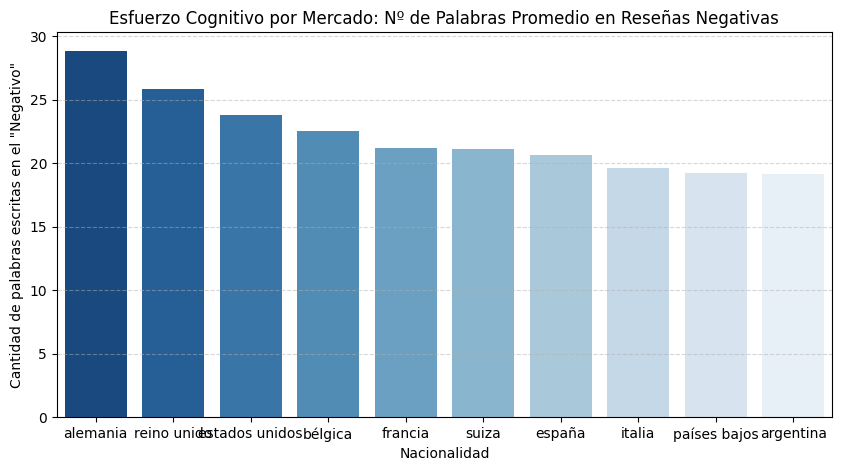

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculamos el conteo de palabras reales en la columna original de quejas (negativo)
df_proyecto['longitud_queja'] = df_proyecto['negativo'].apply(lambda x: len(str(x).split()) if pd.notna(x) and str(x).lower() not in ['nada', 'ninguna', ''] else 0)

# Filtramos filas donde realmente existió una queja (longitud > 0) para no desvirtuar la media
df_quejas_reales = df_proyecto[df_proyecto['longitud_queja'] > 0]

# Agrupamos por nacionalidad para extraer la métrica exacta de esfuerzo verbal
analisis_esfuerzo = df_quejas_reales.groupby('nacionalidad').agg(
    longitud_media_palabras=('longitud_queja', 'mean'),
    maxima_longitud_registrada=('longitud_queja', 'max')
).round(1).sort_values(by='longitud_media_palabras', ascending=False)

print("--- NÚMERO DE PALABRAS EN LA QUEJA ---")
display(analisis_esfuerzo)

# Gráfico de barras para la entrega/diapositivas
plt.figure(figsize=(10, 5))
sns.barplot(data=df_quejas_reales, x='nacionalidad', y='longitud_queja', errorbar=None, palette='Blues_r', order=analisis_esfuerzo.index)
plt.title('Esfuerzo Cognitivo por Mercado: Nº de Palabras Promedio en Reseñas Negativas')
plt.xlabel('Nacionalidad')
plt.ylabel('Cantidad de palabras escritas en el "Negativo"')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

Nota media según la habitación que se haya escogido.

In [22]:
import pandas as pd

print("--- NOTA MEDIA SEGÚN EL TIPO DE VIAJERO ---")
analisis_viajero = df_proyecto.groupby('detalles_hab')['nota'].agg(['mean', 'count']).round(2)
display(analisis_viajero)

# Extraemos qué queja domina en cada tipo de cliente (ejemplo con España)
df_es = df_proyecto[df_proyecto['nacionalidad'] == 'españa']
for tipo in df_es['detalles_hab'].dropna().unique()[:3]:
    df_sub = df_es[df_es['detalles_hab'] == tipo]
    print(f"\nTop menciones de quejas para el segmento [{tipo}]:")
    print(df_sub['negativo_clean'].str.split(expand=True).stack().value_counts().head(3))

--- NOTA MEDIA SEGÚN EL TIPO DE VIAJERO ---


,mean,count
detalles_hab,,
2 habitaciones dobles deluxe comunicadas,9.05,86
alojamiento the level supreme,8.97,142
cama en habitación compartida mixta de 4 camas,8.32,398
cama en habitación compartida mixta de 6 camas,8.13,305
cama en habitación compartida mixta de 8 camas,8.33,273
...,...,...
suite junior con vistas al mar,8.21,90
suite junior supreme the level,9.06,62
suite presidencial the level,9.20,5



Top menciones de quejas para el segmento [2 habitaciones dobles deluxe comunicadas]:
piscina      3
funcionar    3
pequeño      2
Name: count, dtype: int64

Top menciones de quejas para el segmento [habitación doble estándar con vistas a la plaza del ayuntamiento]:
pequeño    10
haber       7
más         7
Name: count, dtype: int64

Top menciones de quejas para el segmento [habitación estándar]:
pequeño    36
baño       24
gustar     20
Name: count, dtype: int64


Clasificamos las nacionalidades en dos grandes bloques geográficos según su distancia y proximidad cultural con el destino: el entorno europeo y el mercado intercontinental de larga distancia. A continuación, aplicamos esta segmentación al conjunto de datos para calcular la nota media de cada bloque, contrastando si el factor de la distancia física influye de manera directa en las expectativas y el nivel de exigencia numérica del turista.

In [23]:
import pandas as pd

# Definimos los bloques geográficos basados en tus países
paises_proximidad = ['españa', 'francia', 'italia', 'reino unido', 'países bajos', 'alemania', 'suiza', 'bélgica']
paises_distancia = ['argentina', 'estados unidos']

# Creamos la nueva variable de segmentación cultural
def asignar_bloque(pais):
    if pais in paises_proximidad: return 'Europa (Proximidad)'
    if pais in paises_distancia: return 'Intercontinental (Larga Distancia)'
    return 'Otros'

df_proyecto['bloque_cultural'] = df_proyecto['nacionalidad'].apply(asignar_bloque)

# Comparamos las notas medias para ver el impacto reputacional
print("--- NOTA MEDIA POR BLOQUE GEOGRÁFICO ---")
print(df_proyecto.groupby('bloque_cultural')['nota'].mean().round(2))

# Extraemos el Top de quejas para ver si se rompe la homogeneidad
print("\n--- QUEJAS TOP: EUROPA ---")
df_euro = df_proyecto[df_proyecto['bloque_cultural'] == 'Europa (Proximidad)']
print(df_euro['negativo_clean'].value_counts().head(5))

print("\n--- QUEJAS TOP: INTERCONTINENTAL ---")
df_inter = df_proyecto[df_proyecto['bloque_cultural'] == 'Intercontinental (Larga Distancia)']
print(df_inter['negativo_clean'].value_counts().head(5))

--- NOTA MEDIA POR BLOQUE GEOGRÁFICO ---
bloque_cultural
Europa (Proximidad)                   8.42
Intercontinental (Larga Distancia)    8.81
Name: nota, dtype: float64

--- QUEJAS TOP: EUROPA ---
negativo_clean
                26853
gustar            162
perfecto          161
pequeño            83
baño pequeño       62
Name: count, dtype: int64

--- QUEJAS TOP: INTERCONTINENTAL ---
negativo_clean
            1630
perfecto      14
gustar        13
queja          9
pequeño        9
Name: count, dtype: int64


Personas que se quejan en la columna de comentarios positivos.

In [24]:
# Buscamos palabras típicamente negativas ('pero', 'malo', 'pequeño', 'viejo', 'ruido') dentro de la columna de POSITIVOS
palabras_criticas = ['pero', 'pequeno', 'pequeño', 'ruido', 'antiguo', 'viejo', 'caro', 'defecto']

df_proyecto['critica_infiltrada'] = df_proyecto['positivo_clean'].fillna("").apply(
    lambda x: 1 if any(p in str(x).lower() for p in palabras_criticas) else 0
)

print("--- PORCENTAJE DE CLIENTES QUE SE QUEJAN INCLUSO EN LA COLUMNA DE POSITIVOS ---")
critica_cultural = df_proyecto.groupby('nacionalidad')['critica_infiltrada'].mean() * 100
display(critica_cultural.sort_values(ascending=False).round(1))

--- PORCENTAJE DE CLIENTES QUE SE QUEJAN INCLUSO EN LA COLUMNA DE POSITIVOS ---


nacionalidad
alemania          6.0
reino unido       5.4
bélgica           4.8
países bajos      4.4
francia           4.1
estados unidos    3.8
suiza             3.6
italia            2.7
argentina         1.9
españa            1.8
Name: critica_infiltrada, dtype: float64

Análisis de especificidad que aísla el ruido de las quejas masivas. Primero binarizamos el texto libre generando variables categóricas para los seis problemas más recurrentes y construimos. Aplicamos un test estadístico de Chi-cuadrado para modelar las frecuencias teóricas globales y calculamos la matriz de residuos estandarizados.

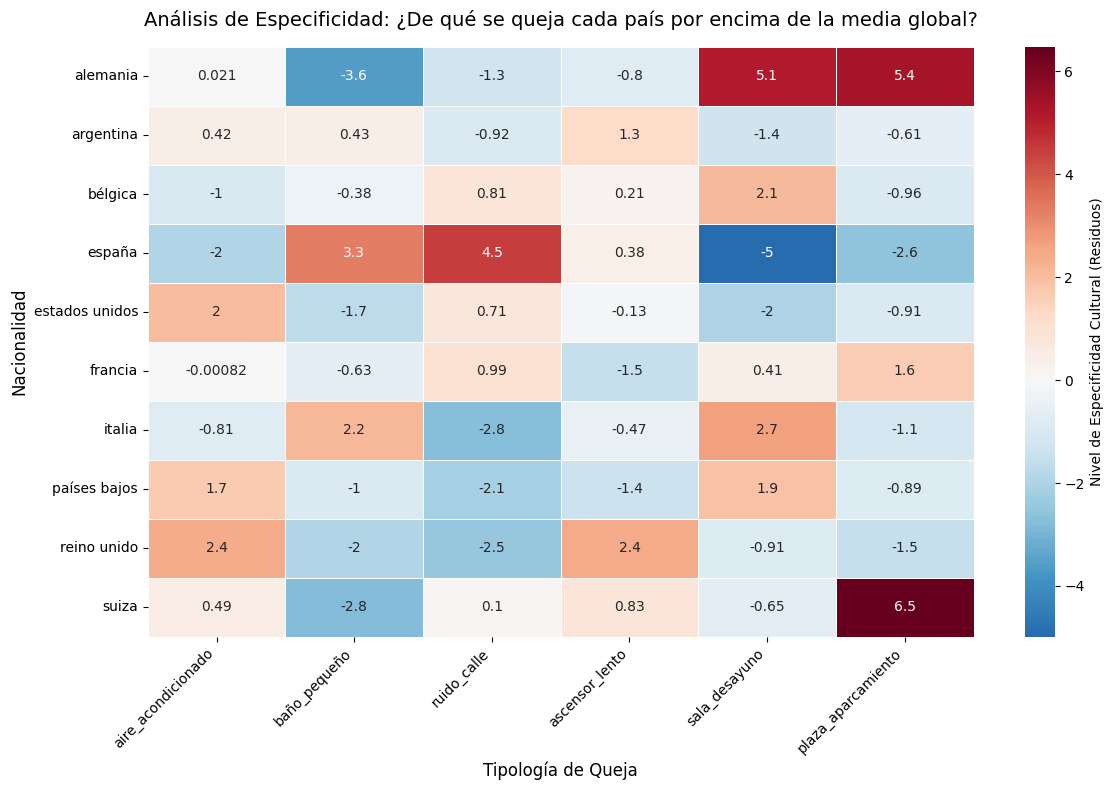

In [25]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

# Creamos las variables dummy de las quejas clave en el dataset general
df_proyecto['aire_acondicionado'] = df_proyecto['negativo_clean'].fillna("").str.contains('aire acondicionado').astype(int)
df_proyecto['baño_pequeño'] = df_proyecto['negativo_clean'].fillna("").str.contains('baño pequeño').astype(int)
df_proyecto['ruido_calle'] = df_proyecto['negativo_clean'].fillna("").str.contains('ruido calle').astype(int)
df_proyecto['ascensor_lento'] = df_proyecto['negativo_clean'].fillna("").str.contains('ascensor lento').astype(int)
df_proyecto['sala_desayuno'] = df_proyecto['negativo_clean'].fillna("").str.contains('sala desayuno').astype(int)
df_proyecto['plaza_aparcamiento'] = df_proyecto['negativo_clean'].fillna("").str.contains('plaza aparcamiento').astype(int)

# Creamos la tabla de contingencia (País vs Quejas) sumando las ocurrencias
lista_quejas = ['aire_acondicionado', 'baño_pequeño', 'ruido_calle', 'ascensor_lento', 'sala_desayuno', 'plaza_aparcamiento']
tabla_contingencia = df_proyecto.groupby('nacionalidad')[lista_quejas].sum()

# Aplicamos el test de Chi-cuadrado para obtener los residuos estandarizados
# Los residuos miden cuánto se aleja la realidad de la media teórica global
chi2, p, dof, esperados = chi2_contingency(tabla_contingencia)
residuos = (tabla_contingencia-esperados)/(esperados ** 0.5)

# Pintamos el mapa de calor de las desviaciones culturales
plt.figure(figsize=(12, 8))
sns.heatmap(
    residuos, 
    annot=True, 
    cmap='RdBu_r', 
    center=0, 
    cbar_kws={'label': 'Nivel de Especificidad Cultural (Residuos)'},
    linewidths=0.5
)

plt.title('Análisis de Especificidad: ¿De qué se queja cada país por encima de la media global?', fontsize=14, pad=15)
plt.xlabel('Tipología de Queja', fontsize=12)
plt.ylabel('Nacionalidad', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()